In [25]:
import pandas as pd
import numpy as np
import pickle
import os
import json
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
import shap
import openai
import nltk
import dice_ml


from sklearn.model_selection import train_test_split
from sklearn.model_selection import train_test_split
from sklearn.model_selection import train_test_split
from lingam import VARLiNGAM
from IPython.display import display, Markdown, HTML
from matplotlib.ticker import FormatStrFormatter
from dotenv import load_dotenv
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder,MinMaxScaler
from typing import Dict, List, Optional, Tuple
from sklearn.model_selection import train_test_split

# Download required NLTK data
try:
    nltk.data.find('tokenizers/punkt')
except LookupError:
    nltk.download('punkt')

load_dotenv()

openai_api_key = os.getenv("OPENAI_API_KEY")
groq_api_key = os.getenv("GROQ_API_KEY")

<br> <br>

####  Helper function to determine output folder based on persona

In [26]:
# Helper function to determine output folder based on persona
def get_output_folder_for_persona(persona: str, base_path: str = "llm_response/counterfactual") -> str:
    """
    Generate output folder path based on persona
    
    Args:
        persona: Either "data_scientist" or "operator"
        base_path: Base path for LLM responses
        
    Returns:
        Complete path with persona-specific subfolder
    """
    if persona == "data_scientist":
        return f"{base_path}/data_scientist"
    elif persona == "operator":
        return f"{base_path}/machine_operator"
    else:
        # Default fallback
        return f"{base_path}/{persona}"

print("✅ Helper function for persona-based paths loaded")

✅ Helper function for persona-based paths loaded


<br> <br> <br>

## Load dataset, feature engineering and pre-processing

In [27]:
# Load the AI4I 2020 dataset
print("📊 Loading AI4I 2020 Dataset for Causality Analysis")
print("=" * 60)


def feature_engineering(df):

    # scaler = StandardScaler()
    # label_encoder = LabelEncoder()
    minmax_scaler = MinMaxScaler()
    encoder = OrdinalEncoder(categories=[["L", "M", "H"]])

    df.rename(
        columns={
            "Air temperature [K]": "Air_temperature",
            "Process temperature [K]": "Process_temperature",
            "Rotational speed [rpm]": "Rotational_speed",
            "Torque [Nm]": "Torque",
            "Tool wear [min]": "Tool_wear",
            "Failure Type": "Failure_Type",
        },
        inplace=True,
    )

    # Engineered Features
    df["Power_output"] = df["Torque"] * df["Rotational_speed"]
    df["wear_torque_product"] = df["Tool_wear"] * df["Torque"]
    df["Temp_difference"] = np.abs(df["Air_temperature"] - df["Process_temperature"])

    # exclude_columns = ["Type", "Failure Type"]
    mapping = {"L": 1, "M": 2, "H": 3}
    df["Type_n"] = df["Type"].map(mapping)
    df["Type_n"] = encoder.fit_transform(df[["Type"]]).astype(int)

    exclude_columns = ["Failure_Type", "Target", "Type_n"]

    df.drop(columns=["Product ID", "UDI", "Type"], inplace=True)

    # Columns to scale
    columns_to_scale = [col for col in df.columns if col not in exclude_columns]

    df_minmax = df.copy()
    df_minmax[columns_to_scale] = minmax_scaler.fit_transform(
        df_minmax[columns_to_scale]
    )
    df_minmax = pd.concat(
        [df_minmax[columns_to_scale], df_minmax[exclude_columns]], axis=1
    )

    return df_minmax


# Load the predictive maintenance dataset
# df_pm = pd.read_csv(os.path.join(paths['data_path'], 'ai4i_2020', 'predictive_maintenance.csv'))
df_pm = pd.read_csv("../../data/ai4i_2020/predictive_maintenance.csv")


# Count rows before filtering
rows_before = len(df_pm)

# Remove rows where Target is 1 and Failure_Type is "No Failure" --> (Noise)
df_pm = df_pm[~((df_pm['Target'] == 1) & (df_pm['Failure Type'] == "No Failure"))]

# Count rows after filtering
rows_after = len(df_pm)
print(f"📝 Removed {rows_before - rows_after} noise rows (Target=1 & Failure_Type='No Failure')")

# Apply feature engineering
df_processed = feature_engineering(df_pm)

# Remove Random Failures (as discussed in previous analysis)
df_processed = df_processed[df_processed['Failure_Type'] != 'Random Failures']

print(f"📊 Dataset shape after preprocessing: {df_processed.shape}")
print(f"🎯 Target distribution: {df_processed['Target'].value_counts().to_dict()}")
print(f"📋 Available features: {list(df_processed.columns)}")

📊 Loading AI4I 2020 Dataset for Causality Analysis
📝 Removed 9 noise rows (Target=1 & Failure_Type='No Failure')
📊 Dataset shape after preprocessing: (9973, 11)
🎯 Target distribution: {0: 9643, 1: 330}
📋 Available features: ['Air_temperature', 'Process_temperature', 'Rotational_speed', 'Torque', 'Tool_wear', 'Power_output', 'wear_torque_product', 'Temp_difference', 'Failure_Type', 'Target', 'Type_n']


In [28]:
df_processed.head()

,Air_temperature,Process_temperature,Rotational_speed,Torque,Tool_wear,Power_output,wear_torque_product,Temp_difference,Failure_Type,Target,Type_n
0,0.304348,0.358025,0.222934,0.535714,0.000000,0.622557,0.000000,0.644444,No Failure,0,1
1,0.315217,0.370370,0.139697,0.583791,0.011858,0.609161,0.008420,0.644444,No Failure,0,0
2,0.304348,0.345679,0.192084,0.626374,0.019763,0.708143,0.014972,0.622222,No Failure,0,0
3,0.315217,0.358025,0.154249,0.490385,0.027668,0.512694,0.016761,0.622222,No Failure,0,0
4,0.315217,0.370370,0.139697,0.497253,0.035573,0.509509,0.021822,0.644444,No Failure,0,0


In [29]:

# Drop columns not used for features
X = df_processed.drop(columns=["Target", "Failure_Type"])
y = df_processed["Target"]

# Split into train and test sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train distribution:\n{y_train.value_counts()}")
print(f"y_test distribution:\n{y_test.value_counts()}")

X_train shape: (7978, 9)
X_test shape: (1995, 9)
y_train distribution:
0    7714
1     264
Name: Target, dtype: int64
y_test distribution:
0    1929
1      66
Name: Target, dtype: int64


<br> <br> <br>

## Causality


In [30]:
# Prepare features for causality analysis
print("🔧 Preparing Features for Causality Analysis")
print("=" * 60)

# Define the key features to analyze for causality
# These are the core predictive maintenance features from AI4I 2020 dataset
features_for_causality = [
    'Air_temperature',
    'Process_temperature', 
    'Rotational_speed',
    'Torque',
    'Tool_wear',
    'Power_output',
    'wear_torque_product',
    'Temp_difference',
    'Type_n',  # Machine type
    'Target'   # Include Target to analyze relationships with features
]

# Validate all features exist in the dataset
available_features = [f for f in features_for_causality if f in df_processed.columns]
missing_features = [f for f in features_for_causality if f not in df_processed.columns]

if missing_features:
    print(f"⚠️  Features not found in dataset: {missing_features}")
    features_for_causality = available_features

print(f"✅ Features selected for causality analysis ({len(features_for_causality)}):")
for i, feature in enumerate(features_for_causality, 1):
    print(f"   {i}. {feature}")

print(f"\n📊 Feature matrix shape: {df_processed[features_for_causality].shape}")
print(f"🎯 Target variable included in causality analysis")

🔧 Preparing Features for Causality Analysis
✅ Features selected for causality analysis (10):
   1. Air_temperature
   2. Process_temperature
   3. Rotational_speed
   4. Torque
   5. Tool_wear
   6. Power_output
   7. wear_torque_product
   8. Temp_difference
   9. Type_n
   10. Target

📊 Feature matrix shape: (9973, 10)
🎯 Target variable included in causality analysis


In [31]:
def create_causality_ai4i_2020(df: pd.DataFrame, features_to_analyze: List[str], save_path: str, regularize: bool = True, noise_level: float = 1e-4,
                               include_target: bool = True, allow_self_loops: bool = False, ) -> Tuple[List[Dict], plt.Figure]:
    """
    Create causality analysis using VARLiNGAM for the AI4I 2020 dataset.

    Args:
        df: DataFrame containing the processed AI4I 2020 dataset
        features_to_analyze: List of feature names to include in causality analysis
        save_path: Path to save the causality graph JSON file
        regularize: Whether to apply regularization if LinAlgError occurs
        noise_level: Standard deviation of noise to add during regularization
        include_target: Whether to include the Target variable in the analysis
        allow_self_loops: If False, self-referencing edges are removed
    Returns:
        Tuple containing:
        - List of dictionaries representing causal relationships
        - Matplotlib figure object of the causal network graph
    """
    print("🔍 Starting Causality Analysis for AI4I 2020 Dataset")
    print("=" * 60)

    # Prepare feature list
    analysis_features = features_to_analyze.copy()
    if include_target and "Target" not in analysis_features:
        analysis_features.append("Target")

    # Validate features exist in dataframe
    missing_features = [f for f in analysis_features if f not in df.columns]
    if missing_features:
        raise ValueError(f"Features not found in dataframe: {missing_features}")

    print(f"📊 Features to analyze: {len(analysis_features)}")
    print(f"   {analysis_features}")

    # Extract data for analysis
    X_causal = df[analysis_features].values
    print(f"📈 Data shape for causality analysis: {X_causal.shape}")

    # Initialize the VARLiNGAM model
    print("\n🤖 Initializing VARLiNGAM model...")
    model = VARLiNGAM()

    # Attempt to fit the model with error handling
    try:
        print("🔄 Fitting VARLiNGAM model...")
        model.fit(X_causal)
        print("✅ Model fitted successfully!")

    except np.linalg.LinAlgError as e:
        print(f"⚠️  LinAlgError encountered: {e}")

        if regularize:
            print(f"🔧 Applying regularization with noise level: {noise_level}")
            X_causal_regularized = X_causal + np.random.normal(
                0, noise_level, X_causal.shape
            )
            model.fit(X_causal_regularized)
            print("✅ Model fitted successfully with regularization!")
        else:
            print("❌ Regularization disabled. Raising error.")
            raise e

    # Retrieve the adjacency matrices
    adjacency_matrices = model.adjacency_matrices_
    print(f"📊 Number of adjacency matrices (lags): {len(adjacency_matrices)}")

    # Build causal relationships
    print("\n🔗 Building causal relationships...")
    G = nx.DiGraph()
    G.add_nodes_from(analysis_features)
    n_features = len(analysis_features)
    causal_relationships = []

    # Process each adjacency matrix (one per lag)
    total_edges = 0
    for lag_index, adj_matrix in enumerate(adjacency_matrices):
        lag_edges = 0

        for i in range(n_features):
            for j in range(n_features):
                weight = adj_matrix[i, j]

                if abs(weight) > 1e-6:  # Filter out very small weights
                    source_feature = analysis_features[i]
                    target_feature = analysis_features[j]

                    # Remove self-loops if not allowed
                    if not allow_self_loops and source_feature == target_feature:
                        continue

                    edge_dict = {
                        "source_feature": source_feature,
                        "target_feature": target_feature,
                        "effect_strength": float(weight),
                        "lag": lag_index,
                    }

                    causal_relationships.append(edge_dict)
                    G.add_edge(
                        source_feature, target_feature, weight=weight, lag=lag_index
                    )
                    lag_edges += 1

        if lag_edges > 0:
            print(f"   Lag {lag_index}: {lag_edges} causal relationships found")
        total_edges += lag_edges

    print(f"📈 Total causal relationships found: {total_edges}")

    # Create visualization
    print("\n🎨 Creating causality visualization...")
    fig, ax = plt.subplots(figsize=(14, 10))

    if total_edges > 0:
        # Use spring layout for better visualization
        pos = nx.spring_layout(G, k=2.0, iterations=50, seed=42)

        # Separate Target node visually if included
        if include_target and "Target" in analysis_features:
            # Color nodes differently
            node_colors = [
                "#FF6B6B" if node == "Target" else "#4ECDC4" for node in G.nodes()
            ]
            node_sizes = [2000 if node == "Target" else 1500 for node in G.nodes()]
        else:
            node_colors = ["#4ECDC4"] * len(G.nodes())
            node_sizes = [1500] * len(G.nodes())

        # Draw nodes
        nx.draw_networkx_nodes(
            G,
            pos,
            node_color=node_colors,
            node_size=node_sizes,
            alpha=0.8,
            edgecolors="black",
            linewidths=2,
            ax=ax,
        )

        # Draw edges with different colors for positive/negative effects
        edges = G.edges(data=True)
        positive_edges = [(u, v) for u, v, d in edges if d["weight"] > 0]
        negative_edges = [(u, v) for u, v, d in edges if d["weight"] < 0]

        # Draw positive edges (green)
        if positive_edges:
            pos_weights = [abs(G[u][v]["weight"]) * 3 for u, v in positive_edges]
            nx.draw_networkx_edges(
                G,
                pos,
                edgelist=positive_edges,
                width=pos_weights,
                edge_color="#27AE60",
                arrowsize=20,
                arrowstyle="->",
                alpha=0.7,
                ax=ax,
            )

        # Draw negative edges (red)
        if negative_edges:
            neg_weights = [abs(G[u][v]["weight"]) * 3 for u, v in negative_edges]
            nx.draw_networkx_edges(
                G,
                pos,
                edgelist=negative_edges,
                width=neg_weights,
                edge_color="#E74C3C",
                arrowsize=20,
                arrowstyle="->",
                alpha=0.7,
                ax=ax,
            )

        # Draw labels
        nx.draw_networkx_labels(
            G, pos, font_size=10, font_weight="bold", font_color="white", ax=ax
        )

        # Draw edge labels for significant relationships
        edge_labels = {}
        for u, v, d in G.edges(data=True):
            if abs(d["weight"]) > 0.1:  # Only show labels for stronger relationships
                edge_labels[(u, v)] = f"{d['weight']:.2f}"

        nx.draw_networkx_edge_labels(
            G,
            pos,
            edge_labels=edge_labels,
            font_size=8,
            font_color="black",
            bbox=dict(boxstyle="round,pad=0.2", facecolor="white", alpha=0.8),
            ax=ax,
        )

    else:
        # No causal relationships found
        ax.text(
            0.5,
            0.5,
            "No significant causal relationships found",
            horizontalalignment="center",
            verticalalignment="center",
            transform=ax.transAxes,
            fontsize=14,
            fontweight="bold",
        )

    # Set title and styling
    ax.set_title(
        "Causal Network Graph for AI4I 2020 Dataset\n(VARLiNGAM Analysis)",
        fontsize=16,
        fontweight="bold",
        pad=20,
    )
    ax.axis("off")

    # Add legend
    if total_edges > 0:
        legend_elements = [
            plt.Line2D(
                [0], [0], color="#27AE60", linewidth=3, label="Positive Causal Effect"
            ),
            plt.Line2D(
                [0], [0], color="#E74C3C", linewidth=3, label="Negative Causal Effect"
            ),
        ]
        if include_target:
            legend_elements.extend(
                [
                    plt.Line2D(
                        [0],
                        [0],
                        marker="o",
                        color="w",
                        markerfacecolor="#FF6B6B",
                        markersize=12,
                        label="Target Variable",
                    ),
                    plt.Line2D(
                        [0],
                        [0],
                        marker="o",
                        color="w",
                        markerfacecolor="#4ECDC4",
                        markersize=12,
                        label="Feature Variables",
                    ),
                ]
            )

        ax.legend(
            handles=legend_elements,
            loc="upper center",
            bbox_to_anchor=(0.5, -0.05),
            ncol=2,
            frameon=True,
            fontsize=10,
        )

    plt.tight_layout()

    # Save causal relationships to JSON file
    print(f"\n💾 Saving causal relationships to: {save_path}")
    os.makedirs(os.path.dirname(save_path), exist_ok=True)

    with open(save_path, "w") as f:
        json.dump(causal_relationships, f, indent=2)

    print(f"✅ Causality analysis completed!")
    print(f"   📊 {total_edges} causal relationships identified")
    print(f"   📁 Results saved to: {save_path}")

    return causal_relationships, fig



🔗 Creating Causality Analysis for AI4I 2020 Dataset (Whole Dataset)
🚀 Running VARLiNGAM causality analysis on whole dataset...
🔍 Starting Causality Analysis for AI4I 2020 Dataset
📊 Features to analyze: 10
   ['Air_temperature', 'Process_temperature', 'Rotational_speed', 'Torque', 'Tool_wear', 'Power_output', 'wear_torque_product', 'Temp_difference', 'Type_n', 'Target']
📈 Data shape for causality analysis: (9973, 10)

🤖 Initializing VARLiNGAM model...
🔄 Fitting VARLiNGAM model...
✅ Model fitted successfully!
📊 Number of adjacency matrices (lags): 2

🔗 Building causal relationships...
   Lag 0: 18 causal relationships found
   Lag 1: 20 causal relationships found
📈 Total causal relationships found: 38

🎨 Creating causality visualization...

💾 Saving causal relationships to: causality/counterfactual/causal_graph_whole_dataset.json
✅ Causality analysis completed!
   📊 38 causal relationships identified
   📁 Results saved to: causality/counterfactual/causal_graph_whole_dataset.json
🎉 Causal

,source_feature,target_feature,effect_strength,lag
0,Process_temperature,Air_temperature,1.135802,0
1,Process_temperature,Temp_difference,0.555556,0
2,Rotational_speed,Tool_wear,0.653806,0
3,Rotational_speed,wear_torque_product,-1.079133,0
4,Rotational_speed,Target,0.075775,0
5,Torque,Rotational_speed,-0.324490,0
6,Torque,Tool_wear,-0.061275,0
7,Torque,Power_output,0.869945,0
8,Torque,wear_torque_product,0.095660,0
9,Torque,Target,0.032318,0


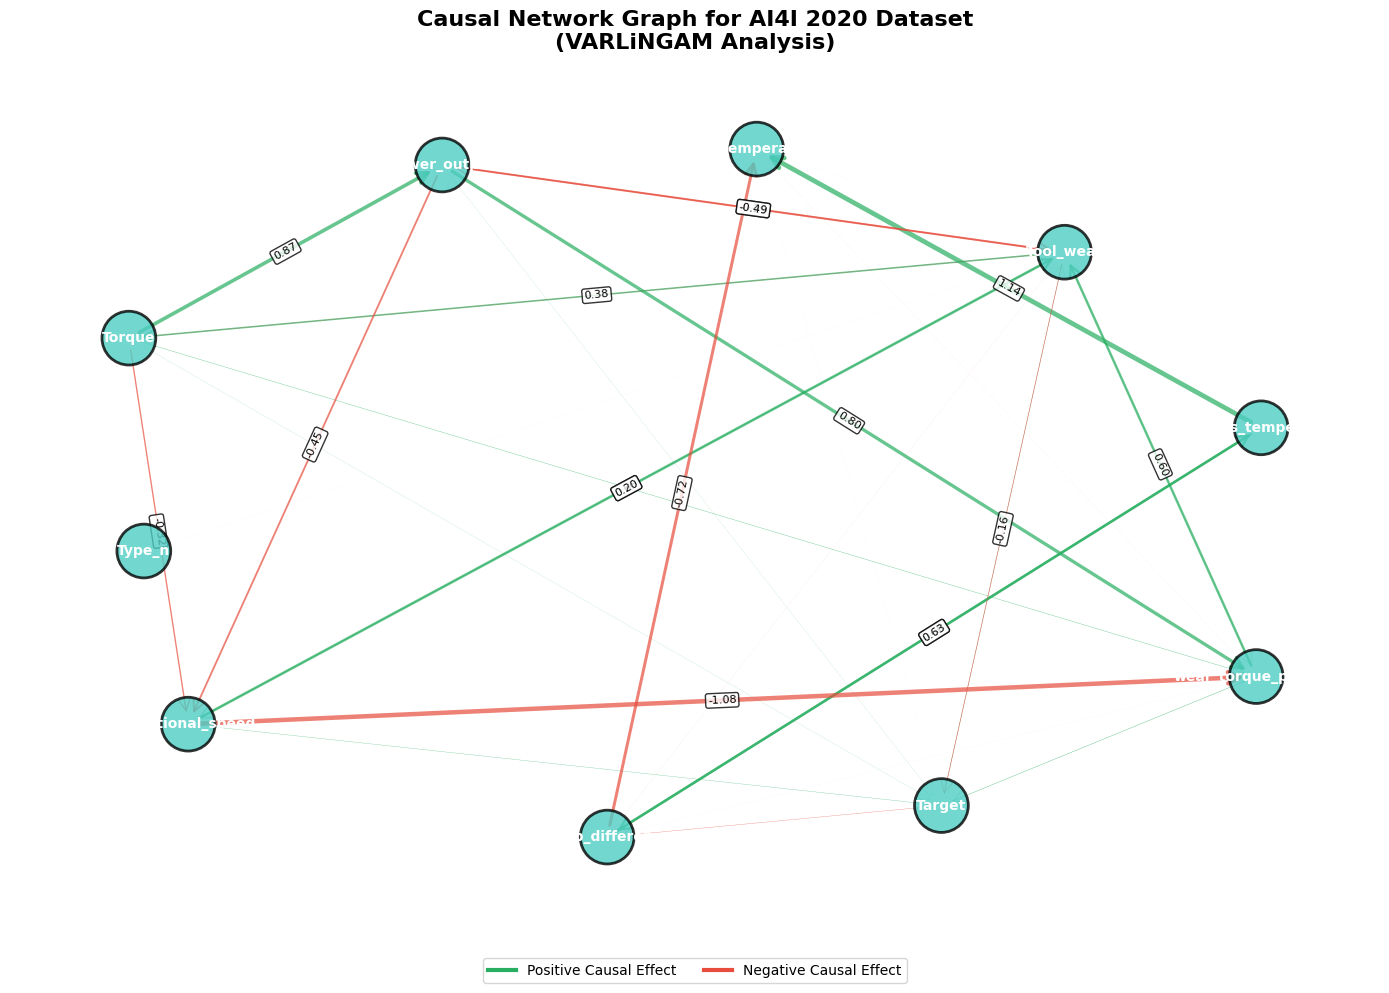


📊 CAUSALITY ANALYSIS SUMMARY:
   📁 JSON saved to: causality/counterfactual/causal_graph_whole_dataset.json
   📊 CSV saved to: causality/counterfactual/causal_graph_whole_dataset.csv
   🔗 Total causal relationships: 38

🏆 TOP 5 STRONGEST CAUSAL RELATIONSHIPS:
   1. Process_temperature → Air_temperature | Effect: +1.1358
   2. Rotational_speed ⊸ wear_torque_product | Effect: -1.0791
   3. Torque          → Power_output    | Effect: +0.8699
   4. Power_output    → wear_torque_product | Effect: +0.7977
   5. Temp_difference ⊸ Air_temperature | Effect: -0.7225

🎯 Target-related relationships: 9
🎯 Target relationships:
   Rotational_speed → Target          | Effect: +0.0758
   Torque          → Target          | Effect: +0.0323
   Power_output    → Target          | Effect: +0.0287
   wear_torque_product → Target          | Effect: +0.0957
   Target          → Tool_wear       | Effect: +0.0665
   Tool_wear       ⊸ Target          | Effect: -0.1594
   Target          → Air_temperature | Effe

In [32]:
# Create Causality Analysis using VARLiNGAM on Whole Dataset
print("🔗 Creating Causality Analysis for AI4I 2020 Dataset (Whole Dataset)")
print("=" * 70)

# Define save paths for causality graph
# causality_save_path = os.path.join(paths['causality_path'], 'ai4i_2020', 'causal_graph_whole_dataset.json')
# causality_csv_path = os.path.join(paths['causality_path'], 'ai4i_2020', 'causal_graph_whole_dataset.csv')
causality_save_path = 'causality/counterfactual/causal_graph_whole_dataset.json'
causality_csv_path = 'causality/counterfactual/causal_graph_whole_dataset.csv'


# Ensure the causality directory exists
os.makedirs(os.path.dirname(causality_save_path), exist_ok=True)

# Create causality analysis on the WHOLE dataset
print("🚀 Running VARLiNGAM causality analysis on whole dataset...")

try:
    causal_relationships, causality_fig = create_causality_ai4i_2020(
        df=df_processed,
        features_to_analyze=features_for_causality,
        save_path=causality_save_path,
        regularize=True,
        noise_level=1e-4,
        include_target=False,  # Target is already in features_for_causality
        allow_self_loops=False,
    )
    
    print("🎉 Causality analysis completed successfully!")
    
    # Convert causal relationships to DataFrame and save as CSV
    if causal_relationships:
        causal_df = pd.DataFrame(causal_relationships)
        causal_df.to_csv(causality_csv_path, index=False)
        print(f"💾 Causality relationships saved as CSV: {causality_csv_path}")
        
        # Display the DataFrame
        print(f"\n📊 Causal Relationships DataFrame:")
        display(causal_df.head(10))
    
    # Display the causality network graph
    plt.show()
    
    # Print summary of causal relationships found
    print(f"\n📊 CAUSALITY ANALYSIS SUMMARY:")
    print(f"   📁 JSON saved to: {causality_save_path}")
    print(f"   📊 CSV saved to: {causality_csv_path}")
    print(f"   🔗 Total causal relationships: {len(causal_relationships)}")
    
    if causal_relationships:
        # Show strongest relationships
        sorted_relationships = sorted(causal_relationships, key=lambda x: abs(x['effect_strength']), reverse=True)
        print(f"\n🏆 TOP 5 STRONGEST CAUSAL RELATIONSHIPS:")
        for i, rel in enumerate(sorted_relationships[:5], 1):
            direction = "→" if rel['effect_strength'] > 0 else "⊸"
            print(f"   {i}. {rel['source_feature']:15s} {direction} {rel['target_feature']:15s} | Effect: {rel['effect_strength']:+.4f}")
        
        # Count relationships involving Target
        target_relationships = [r for r in causal_relationships if 'Target' in [r['source_feature'], r['target_feature']]]
        print(f"\n🎯 Target-related relationships: {len(target_relationships)}")
        
        if target_relationships:
            print("🎯 Target relationships:")
            for rel in target_relationships:
                direction = "→" if rel['effect_strength'] > 0 else "⊸"
                print(f"   {rel['source_feature']:15s} {direction} {rel['target_feature']:15s} | Effect: {rel['effect_strength']:+.4f}")
        
    else:
        print("⚠️  No significant causal relationships detected.")
        
except Exception as e:
    print(f"❌ Error in causality analysis: {str(e)}")
    print("This might be due to data characteristics or VARLiNGAM model constraints.")
    import traceback
    traceback.print_exc()

In [33]:
X = df_processed.drop(columns=["Target", "Failure_Type"])
y = df_processed[["Target", "Failure_Type"]]
X_train, X_test, y_train, y_test = train_test_split(X, y["Target"], test_size=0.2, random_state=42)

<br> <br> 

## Load machine learning models

In [34]:
def load_ml_models(path):
    with open(f"{path}/randomforest.pkl", "rb") as f:
        randomforest_model = pickle.load(f)

    with open(f"{path}/xgboost.pkl", "rb") as f:
        xgboost_model = pickle.load(f)

    with open(f"{path}/catboost.pkl", "rb") as f:
        catboost_model = pickle.load(f)

    with open(f"{path}/lgbmclassifier.pkl", "rb") as f:
        lgbmclassifier_model = pickle.load(f)

    return randomforest_model, xgboost_model, catboost_model, lgbmclassifier_model


ml_models_path = 'model/'
randomforest_model, xgboost_model, catboost_model, lgbmclassifier_model = load_ml_models(path=ml_models_path)


<br> <br> <br>

## Choose random failure from X_test

In [35]:
def build_failure_sample(
    df_processed: pd.DataFrame,
    X_test: pd.DataFrame,
    target_col: str = "Target",
    failure_col: str = "Failure_Type",
    per_type: int = 10,
    special_rules: dict | None = None,
    random_state: int = 42,
    shuffle_within: bool = True,
    return_features_only: bool = False
) -> pd.DataFrame:
    """
    Build a balanced (or rule-based) failure sample from the X_test portion
    of the processed dataframe.
    """
    if special_rules is None:
        special_rules = {}

    # Validate required columns exist
    required_cols = [target_col, failure_col]
    missing = [c for c in required_cols if c not in df_processed.columns]
    if missing:
        raise ValueError(f"Missing required columns in df_processed: {missing}")

    # Ensure X_test indices exist in df_processed
    missing_indices = set(X_test.index) - set(df_processed.index)
    if missing_indices:
        raise ValueError(f"X_test contains indices not found in df_processed: {list(missing_indices)[:5]}...")

    # Filter df_processed to only include rows that are in X_test
    test_full = df_processed.loc[X_test.index].copy()
    
    # Verify we have the same number of rows
    assert len(test_full) == len(X_test), f"Mismatch: test_full has {len(test_full)} rows, X_test has {len(X_test)} rows"

    # Filter to only failure cases (target == 1)
    failures = test_full[test_full[target_col] == 1].copy()
    if failures.empty:
        raise ValueError("No failure rows (target==1) found in X_test subset.")

    print(f"📊 Found {len(failures)} failure rows in X_test")
    print(f"📊 Failure type distribution:")
    print(failures[failure_col].value_counts())

    # Set random seed for reproducibility
    np.random.seed(random_state)
    sampled_groups = []

    for ftype, grp in failures.groupby(failure_col):
        rule = special_rules.get(ftype, per_type)
        if (rule is None) or (isinstance(rule, (int, float)) and rule <= 0):
            # Take all available rows for this failure type
            take_n = len(grp)
        else:
            # Take specified number or all available (whichever is smaller)
            take_n = min(int(rule), len(grp))

        if take_n < len(grp) and shuffle_within:
            # Randomly sample the specified number
            sampled = grp.sample(n=take_n, random_state=random_state)
        else:
            # Take all available or take first n rows
            sampled = grp if take_n == len(grp) else grp.head(take_n)

        sampled_groups.append(sampled)
        print(f"   {ftype}: selected {len(sampled)}/{len(grp)} rows")

    if not sampled_groups:
        raise ValueError("No samples were selected from any failure type")

    # Combine all sampled groups
    sampled_df = pd.concat(sampled_groups, axis=0)
    
    # Sort by failure type for better readability - DON'T reset index
    sampled_df = sampled_df.sort_values([failure_col])

    # Verify all selected indices exist in X_test
    selected_indices = set(sampled_df.index)
    x_test_indices = set(X_test.index)
    invalid_indices = selected_indices - x_test_indices
    
    if invalid_indices:
        print(f"⚠️ Warning: Found {len(invalid_indices)} indices not in X_test: {list(invalid_indices)[:5]}")
        # Filter out invalid indices
        sampled_df = sampled_df[sampled_df.index.isin(x_test_indices)]

    # Final verification
    final_indices = set(sampled_df.index)
    assert final_indices.issubset(x_test_indices), "Some selected indices are still not in X_test"

    # Report final results
    print("=== Failure Sampling Summary ===")
    print(f"Total failure rows in X_test: {len(failures)}")
    print(f"Selected rows: {len(sampled_df)}")
    print("Final counts per failure type:")
    print(sampled_df[failure_col].value_counts())

    if return_features_only:
        feature_cols = [c for c in sampled_df.columns if c not in [target_col, failure_col]]
        return sampled_df[feature_cols].copy()

    return sampled_df


In [36]:
# Usage with verification
# selected_failures_df = build_failure_sample(df_processed=df_processed, X_test=X_test, per_type=10, special_rules={"Tool Wear Failure": None},  random_state=42)
selected_failures_df = build_failure_sample(df_processed=df_processed, X_test=X_test, per_type=3, random_state=42)
# "Tool Wear Failure": None => It means take all of them

# Additional verification step
print("\n🔍 Verification:")
if 'index' in selected_failures_df.columns:
    selected_indices = set(selected_failures_df['index'])
else:
    selected_indices = set(selected_failures_df.index)

x_test_indices = set(X_test.index)
indices_not_in_x_test = selected_indices - x_test_indices

if indices_not_in_x_test:
    print(f"❌ ERROR: {len(indices_not_in_x_test)} selected indices are NOT in X_test:")
    print(f"   Examples: {list(indices_not_in_x_test)[:10]}")
else:
    print("✅ SUCCESS: All selected indices exist in X_test")

print(f"📊 Selected indices range: {min(selected_indices)} to {max(selected_indices)}")
print(f"📊 X_test indices range: {min(x_test_indices)} to {max(x_test_indices)}")

📊 Found 59 failure rows in X_test
📊 Failure type distribution:
Heat Dissipation Failure    23
Power Failure               23
Overstrain Failure           8
Tool Wear Failure            5
Name: Failure_Type, dtype: int64
   Heat Dissipation Failure: selected 3/23 rows
   Overstrain Failure: selected 3/8 rows
   Power Failure: selected 3/23 rows
   Tool Wear Failure: selected 3/5 rows
=== Failure Sampling Summary ===
Total failure rows in X_test: 59
Selected rows: 12
Final counts per failure type:
Heat Dissipation Failure    3
Overstrain Failure          3
Power Failure               3
Tool Wear Failure           3
Name: Failure_Type, dtype: int64

🔍 Verification:
✅ SUCCESS: All selected indices exist in X_test
📊 Selected indices range: 259 to 4723
📊 X_test indices range: 0 to 9998


In [37]:
selected_failures_df

,Air_temperature,Process_temperature,Rotational_speed,Torque,Tool_wear,Power_output,wear_torque_product,Temp_difference,Failure_Type,Target,Type_n
4449,0.771739,0.567901,0.122235,0.693681,0.652174,0.717403,0.543099,0.066667,Heat Dissipation Failure,1,1
4723,0.880435,0.753086,0.115250,0.646978,0.790514,0.657906,0.617082,0.177778,Heat Dissipation Failure,1,0
4383,0.695652,0.469136,0.075669,0.847527,0.905138,0.831920,0.909226,0.044444,Heat Dissipation Failure,1,0
2761,0.489130,0.444444,0.076251,0.842033,0.837945,0.826819,0.836588,0.422222,Overstrain Failure,1,0
3528,0.728261,0.641975,0.122235,0.677198,0.837945,0.698826,0.682379,0.288889,Overstrain Failure,1,0
586,0.250000,0.481481,0.193830,0.631868,0.877470,0.716553,0.670158,0.977778,Overstrain Failure,1,0
3579,0.706522,0.604938,0.875437,0.109890,0.490119,0.231007,0.088695,0.266667,Power Failure,1,0
603,0.282609,0.506173,0.097788,0.931319,0.122530,0.951437,0.134546,0.955556,Power Failure,1,0
259,0.304348,0.308642,0.146682,0.825549,0.075099,0.896169,0.073595,0.555556,Power Failure,1,1
3611,0.695652,0.641975,0.137951,0.585165,0.818182,0.609179,0.582215,0.355556,Tool Wear Failure,1,0


<br> <br> <br>

## SHAP

Find the most important features using SHAP

In [38]:
# ************************************************************** SHAP Feature Importance ****************************************************************

def generate_shap_values(model, random_sample, image_name, combined_feature_importance_name, top_n_features=3, class_idx=1, x_axis_labelsize=15, y_axis_labelsize=15, off_switch=False,):
    
    # Generate SHAP values for the sample
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(random_sample)

    # Handle SHAP values based on their structure and model type
    if isinstance(shap_values, list):
        # For models that return a list of arrays (like RF, XGB, LGBM for binary classification)
        feature_importance = np.abs(shap_values[class_idx]).mean(axis=0)
    else:
        # For models that return a single array
        feature_importance = np.abs(shap_values).mean(axis=0)

    # Create DataFrame with feature importances
    shap_feature_importance = pd.DataFrame(
        {"feature": random_sample.columns, "importance": feature_importance}
    )
    shap_feature_importance = shap_feature_importance.sort_values(
        "importance", ascending=False
    )

    # Display the top N important features in a DataFrame
    combined_feature_importance = pd.DataFrame(
        {
            "feature": shap_feature_importance["feature"][:top_n_features].tolist(),
            "importance": shap_feature_importance["importance"][
                :top_n_features
            ].tolist(),
        }
    ).sort_values("importance", ascending=False)

    # Save the combined feature importance DataFrame to a JSON file
    combined_feature_importance.to_json(f"json/{combined_feature_importance_name}.json", orient="records")

    # Get prediction probabilities for the sample
    pred_shap = model.predict_proba(random_sample)[0]

    # Plot the top features and their SHAP values
    plt.figure(figsize=(10, 6))
    plt.barh(
        shap_feature_importance["feature"][:top_n_features][::-1],
        shap_feature_importance["importance"][:top_n_features][::-1],
    )
    # plt.title(f"Top {top_n_features} Important Features from {combined_feature_importance_name}", fontsize=18)
    plt.title(f"Top {top_n_features} Important Features", fontsize=15)
    # plt.xlabel("SHAP Value (absolute)", fontsize=16)

    # Set different font sizes for x-axis and y-axis
    plt.tick_params(
        axis="x", which="major", labelsize=x_axis_labelsize
    )  # X-axis font size
    plt.tick_params(
        axis="y", which="major", labelsize=y_axis_labelsize
    )  # Y-axis font size

    # Format x-axis to have only 2 decimal places
    plt.gca().xaxis.set_major_formatter(FormatStrFormatter("%.2f"))

    plt.tight_layout()
    plt.savefig(image_name)

    if off_switch:
        plt.close()
    else:
        plt.show()

    return shap_values, pred_shap, combined_feature_importance


<br> <br> <br>

## Counterfactual Analysis using Dice

[Dice-ML](https://pypi.org/project/dice-ml/#:~:text=With%20DiCE%2C%20generating%20explanations%20is%20a%20simple%20three-step,models%2C%20with%20or%20without%20their%20original%20training%20data.)

In [39]:
def generate_dice_counterfactuals_for_important_features(model, random_row: pd.DataFrame, important_features: list, X_train: pd.DataFrame, y_train: pd.Series, y_test: pd.Series, 
                                                         num_counterfactuals: int = 5, desired_class: int = 0, random_seed: int = 42 ) -> pd.DataFrame:
    """
    Generate counterfactuals using DiCE focusing only on the most important features.
    
    Args:
        model: Trained ML model
        random_row: Single row DataFrame from X_test to generate counterfactuals for
        important_features: List of important feature names from SHAP
        X_train: Training data for DiCE
        y_train: Training labels for DiCE
        y_test: Test labels to get the actual target for random_row
        num_counterfactuals: Number of counterfactuals to generate
        desired_class: Target class (0 for no failure, 1 for failure)
        random_seed: Random seed for reproducibility
        
    Returns:
        DataFrame with counterfactuals showing only changed features
    """
    print("🎯 Generating DiCE Counterfactuals for Important Features")
    print("=" * 60)
    
    # Get the actual target value for the random_row
    actual_target = y_test.loc[int(random_row.index.values[0])]
    print(f"📊 Original row index: {random_row.index.values[0]}")
    print(f"🎯 Actual target value: {actual_target}")
    print(f"🔄 Desired target value: {desired_class}")
    
    # Prepare training data with target for DiCE
    train_data = X_train.copy()
    train_data['target'] = y_train
    
    # Prepare the query instance with target
    query_instance = random_row.copy()
    query_instance['target'] = actual_target
    
    # Prepare data for DiCE
    d = dice_ml.Data(
        dataframe=train_data,
        continuous_features=list(X_train.columns),
        outcome_name='target'
    )
    
    # Create DiCE model
    m = dice_ml.Model(model=model, backend="sklearn")
    
    # Create DiCE explainer
    exp = dice_ml.Dice(d, m, method="random")
    
    # Generate counterfactuals with constraints on important features only
    print(f"🔍 Focusing on {len(important_features)} important features:")
    for i, feature in enumerate(important_features, 1):
        print(f"   {i}. {feature}")
    
    try:
        # Generate counterfactuals - remove target from query for DiCE
        query_for_dice = random_row.copy()  # This only has features, no target
        
        dice_exp = exp.generate_counterfactuals(
            query_for_dice,
            total_CFs=num_counterfactuals,
            desired_class=desired_class,
            features_to_vary=important_features,  # Only vary important features
            random_seed=random_seed
        )
        
        # Extract counterfactuals
        counterfactuals_df = dice_exp.cf_examples_list[0].final_cfs_df
        
        if counterfactuals_df.empty:
            print("⚠️ No counterfactuals generated")
            return pd.DataFrame()
        
        print(f"✅ Generated {len(counterfactuals_df)} counterfactuals")
        
        # Verify predictions changed
        original_prediction = model.predict(random_row)[0]
        original_proba = model.predict_proba(random_row)[0]
        
        print(f"📊 Original prediction: {original_prediction}")
        print(f"📊 Original probabilities: {original_proba}")
        
        # Analyze changes - compare with original row
        original_values = random_row.iloc[0]
        changes_data = []
        
        for idx, cf_row in counterfactuals_df.iterrows():
            # Get counterfactual features (remove target column if present)
            cf_features = cf_row.drop('target') if 'target' in cf_row.index else cf_row
            cf_features_df = cf_features.to_frame().T
            
            # Verify prediction changed
            cf_prediction = model.predict(cf_features_df)[0]
            cf_proba = model.predict_proba(cf_features_df)[0]
            
            change_info = {
                'counterfactual_id': idx,
                'original_prediction': original_prediction,
                'cf_prediction': cf_prediction,
                'prediction_changed': cf_prediction != original_prediction,
                'original_proba_class_1': original_proba[1],
                'cf_proba_class_1': cf_proba[1]
            }
            
            # Check which features changed
            changed_features = []
            for feature in important_features:
                if feature in original_values.index and feature in cf_features.index:
                    original_val = original_values[feature]
                    cf_val = cf_features[feature]
                    
                    if abs(original_val - cf_val) > 1e-6:  # Feature changed
                        changed_features.append(feature)
                        change_info[f'{feature}_original'] = original_val
                        change_info[f'{feature}_counterfactual'] = cf_val
                        change_info[f'{feature}_change'] = cf_val - original_val
                        change_info[f'{feature}_percent_change'] = ((cf_val - original_val) / original_val * 100) if original_val != 0 else float('inf')
            
            change_info['changed_features'] = ', '.join(changed_features)
            change_info['num_changed_features'] = len(changed_features)
            changes_data.append(change_info)
        
        # Create summary DataFrame
        changes_df = pd.DataFrame(changes_data)
        
        # Display summary
        print(f"\n📊 COUNTERFACTUAL ANALYSIS SUMMARY:")
        print(f"   Original prediction: {original_prediction} (class 1 prob: {original_proba[1]:.3f})")
        print(f"   Generated counterfactuals: {len(counterfactuals_df)}")
        print(f"   Successful prediction changes: {sum(changes_df['prediction_changed'])}")
        
        # Show which features changed across all counterfactuals
        if not changes_df.empty:
            all_changed_features = []
            for cf in changes_data:
                if cf['changed_features']:
                    all_changed_features.extend(cf['changed_features'].split(', '))
            
            if all_changed_features:
                from collections import Counter
                feature_frequency = Counter(all_changed_features)
                print(f"\n🔄 Feature Change Frequency:")
                for feature, count in feature_frequency.most_common():
                    print(f"   {feature}: {count}/{len(counterfactuals_df)} counterfactuals")
        
        return changes_df
        
    except Exception as e:
        print(f"❌ Error generating counterfactuals: {str(e)}")
        import traceback
        traceback.print_exc()
        return pd.DataFrame()


<br> <br> <br>

#### Generate counterfactual summary for LLM

In [40]:
FEATURE_FRIENDLY_NAME_MAP = {
    "Air_temperature": "Air temperature (K)",
    "Process_temperature": "Process temperature (K)",
    "Rotational_speed": "Rotational speed (rpm)",
    "Torque": "Torque (Nm)",
    "Tool_wear": "Tool wear (min)",
    "Power_output": "Power output (Nm·rpm)",
    "wear_torque_product": "Wear × Torque",
    "Temp_difference": "Temperature difference",
    "Type_n": "Machine type",
    "Target": "Failure (target)"
}

def friendly_name(feature: str) -> str:
    """Return user-friendly label for a feature name."""
    if feature is None:
        return feature
    return FEATURE_FRIENDLY_NAME_MAP.get(feature, str(feature).replace("_", " ").title())

def feature_display_label(feature: str) -> str:
    """Return display label in the format: Friendly Name (original_name)."""
    return f"{friendly_name(feature)} ({feature})"

In [41]:
def create_llm_ready_counterfactual_summary(counterfactual_results: pd.DataFrame, model, random_row: pd.DataFrame, important_features: list) -> pd.DataFrame:
    """
    Create a clean summary DataFrame with essential counterfactual information for LLM explanation.
    Outputs include:
      - 'changed_feature_names' (original feature keys, comma separated)
      - 'changed_feature_display' (Friendly Name (original) comma separated)  <-- new
      - 'feature_changes_summary' using friendly display labels
    """
    print("📊 Creating LLM-Ready Counterfactual Summary")
    print("=" * 50)

    if counterfactual_results.empty:
        print("⚠️ No counterfactual results to summarize")
        return pd.DataFrame()

    # Filter to only successful counterfactuals
    successful_cfs = counterfactual_results[counterfactual_results['prediction_changed'] == True]

    if successful_cfs.empty:
        print("⚠️ No successful counterfactuals found")
        return pd.DataFrame()

    # Get original prediction info
    original_prediction = model.predict(random_row)[0]
    original_proba = model.predict_proba(random_row)[0]

    llm_ready_data = []

    for _, row in successful_cfs.iterrows():
        changed_features = []
        changed_displays = []
        feature_changes_text = []

        for feature in important_features:
            key_change = f'{feature}_change'
            if key_change in row and pd.notna(row[key_change]):
                original_val = row.get(f'{feature}_original', None)
                new_val = row.get(f'{feature}_counterfactual', None)
                change_val = row.get(key_change, None)
                percent_change = row.get(f'{feature}_percent_change', None)

                changed_features.append(feature)
                changed_displays.append(feature_display_label(feature))

                # Use friendly display in the detail text: Friendly (orig): old -> new (Delta..., %)
                try:
                    orig_fmt = f"{original_val:.3f}" if pd.notna(original_val) else str(original_val)
                    new_fmt = f"{new_val:.3f}" if pd.notna(new_val) else str(new_val)
                    change_fmt = f"{change_val:+.3f}" if pd.notna(change_val) else str(change_val)
                    pct_fmt = f"{percent_change:+.1f}%" if pd.notna(percent_change) and np.isfinite(percent_change) else ("inf%" if percent_change == float('inf') else str(percent_change))
                except Exception:
                    orig_fmt, new_fmt, change_fmt, pct_fmt = original_val, new_val, change_val, percent_change

                feature_changes_text.append(
                    f"{feature_display_label(feature)}: {orig_fmt} -> {new_fmt} (Delta{change_fmt}, {pct_fmt})"
                )

        llm_data = {
            'counterfactual_id': row['counterfactual_id'],
            'changed_feature_names': ', '.join(changed_features),
            'changed_feature_display': ', '.join(changed_displays),
            'num_changed_features': len(changed_features),
            'original_prediction': original_prediction,
            'original_probability_failure': round(original_proba[1], 3),
            'counterfactual_prediction': row['cf_prediction'],
            'counterfactual_probability_failure': round(row['cf_proba_class_1'], 3),
            'prediction_flip': f"{original_prediction} to {row['cf_prediction']}",
            'probability_change': round(row['cf_proba_class_1'] - original_proba[1], 3),
            'feature_changes_summary': '; '.join(feature_changes_text)
        }

        llm_ready_data.append(llm_data)

    llm_df = pd.DataFrame(llm_ready_data)
    print(f"✅ Created LLM-ready summary with {len(llm_df)} successful counterfactuals")
    return llm_df


<br> <br> <br>


#### Aligning SHAP feature with the main causal graph

In [42]:
def plot_causal_subgraph_for_counterfactuals(
    llm_summary: pd.DataFrame,
    causal_df: pd.DataFrame | None = None,
    causal_relationships: list | None = None,
    selected_features: list | None = None,
    include_target: bool = True,
    figsize: tuple = (10, 8),
    seed: int = 42,
    title: str = "Causal Subgraph for Counterfactual-Selected Features",
    show: bool = True
) -> tuple:
    """
    Build and plot a causal subgraph containing edges where the source or target
    is one of the selected counterfactual features.

    Args:
        llm_summary: DataFrame with at least a 'changed_feature_names' column.
        causal_df: Optional DataFrame with columns ['source_feature','target_feature','effect_strength',...].
        causal_relationships: Optional list of dicts (as produced by create_causality_ai4i_2020).
        selected_features: Optional list of features to focus on. If None, extracted from llm_summary.
        include_target: If True, keep 'Target' if present in nodes (visual highlight).
        figsize: Figure size.
        seed: Seed passed to networkx layout.
        title: Plot title.
        show: Whether to plt.show() the figure.

    Returns:
        (filtered_causal_df, fig, G_sub)
    """
    # Validate llm_summary
    if llm_summary is None or llm_summary.empty:
        raise ValueError("llm_summary is required and must not be empty")

    # Derive selected features if not provided
    if selected_features is None:
        # split by comma and strip whitespace, handle different separators robustly
        split_lists = llm_summary['changed_feature_names'].astype(str).str.split(',')
        selected_features = sorted({s.strip() for sub in split_lists for s in sub if s and s.strip()})
    if not selected_features:
        raise ValueError("No selected features could be derived or provided")

    # Obtain causal dataframe
    if causal_df is None:
        if 'causal_df' in globals() and isinstance(globals()['causal_df'], pd.DataFrame):
            all_causal_df = globals()['causal_df']
        elif causal_relationships is not None:
            all_causal_df = pd.DataFrame(causal_relationships)
        else:
            raise ValueError("Provide either causal_df, causal_relationships, or ensure causal_df exists in globals()")
    else:
        all_causal_df = causal_df

    # Ensure required columns exist
    req_cols = {'source_feature', 'target_feature', 'effect_strength'}
    if not req_cols.issubset(set(all_causal_df.columns)):
        raise ValueError(f"causal_df must contain columns: {req_cols}")

    # Filter edges where either source or target is in selected features
    filtered_causal_df = all_causal_df[
        all_causal_df['source_feature'].isin(selected_features) |
        all_causal_df['target_feature'].isin(selected_features)
    ].copy().reset_index(drop=True)

    # Build graph
    G_sub = nx.DiGraph()
    nodes = set(filtered_causal_df['source_feature']).union(filtered_causal_df['target_feature'])
    G_sub.add_nodes_from(nodes)
    for _, row in filtered_causal_df.iterrows():
        src = row['source_feature']
        tgt = row['target_feature']
        try:
            w = float(row['effect_strength'])
        except Exception:
            w = 0.0
        G_sub.add_edge(src, tgt, weight=w)

    # Visualization
    fig, ax = plt.subplots(figsize=figsize)
    pos = nx.spring_layout(G_sub, k=1.0, iterations=200, seed=seed)

    # Node styling: highlight selected features and (optionally) Target
    node_colors = []
    node_sizes = []
    for n in G_sub.nodes():
        if include_target and n == "Target":
            node_colors.append("#FFD166")
            node_sizes.append(2200)
        elif n in selected_features:
            node_colors.append("#FF6B6B")
            node_sizes.append(1800)
        else:
            node_colors.append("#4ECDC4")
            node_sizes.append(1200)

    nx.draw_networkx_nodes(
        G_sub, pos,
        node_color=node_colors,
        node_size=node_sizes,
        edgecolors="black",
        linewidths=1.5,
        ax=ax
    )

    # Edge styling by sign and magnitude
    pos_edges = [(u, v) for u, v, d in G_sub.edges(data=True) if d.get("weight", 0) > 0]
    neg_edges = [(u, v) for u, v, d in G_sub.edges(data=True) if d.get("weight", 0) < 0]

    if pos_edges:
        pos_widths = [max(0.5, abs(G_sub[u][v]["weight"]) * 2.5) for u, v in pos_edges]
        nx.draw_networkx_edges(G_sub, pos, edgelist=pos_edges, width=pos_widths,
                               edge_color="#27AE60", arrowsize=18, arrowstyle="->", ax=ax, alpha=0.8)
    if neg_edges:
        neg_widths = [max(0.5, abs(G_sub[u][v]["weight"]) * 2.5) for u, v in neg_edges]
        nx.draw_networkx_edges(G_sub, pos, edgelist=neg_edges, width=neg_widths,
                               edge_color="#E74C3C", arrowsize=18, arrowstyle="->", ax=ax, alpha=0.8)

    # Labels and edge labels
    nx.draw_networkx_labels(G_sub, pos, font_size=10, font_weight="bold", font_color="black", ax=ax)
    edge_labels = {(u, v): f"{d['weight']:.2f}" for u, v, d in G_sub.edges(data=True)}
    if edge_labels:
        nx.draw_networkx_edge_labels(
            G_sub, pos, edge_labels=edge_labels,
            font_size=8,
            bbox=dict(facecolor="white", alpha=0.7, boxstyle="round,pad=0.2"),
            ax=ax
        )

    ax.set_title(title, fontsize=14, fontweight="bold")
    ax.axis("off")
    plt.tight_layout()

    if show:
        plt.show()
    else:
        plt.close(fig)

    return filtered_causal_df, fig, G_sub


<br> <br> <br>


## Generate Explanation and Actionable Recommendation 

Generate LLM-based explanations and actionable recommendations informed by counterfactual analysis

In [43]:
def generate_llm_explanation(
    summary_text: str,
    persona: str = "data_scientist",
    llm_provider: str = "openai",
    model_name: Optional[str] = None,
    save_response: bool = True,
    random_row_index: Optional[int] = None
) -> Dict:
    """
    Generate LLM explanation for counterfactual analysis with persona-specific prompts.
    
    Args:
        summary_text: The counterfactual summary text to analyze
        persona: Either "data_scientist" or "machine_operator" 
        llm_provider: Either "openai" or "groq"
        model_name: Specific model to use (optional)
        save_response: Whether to save the response to file
        random_row_index: Index of the analyzed row for file naming
        
    Returns:
        Dictionary containing the LLM response and metadata
    """
    print(f"🤖 Generating {llm_provider.upper()} explanation for {persona}")
    print("=" * 60)
    
    # Convert numpy int64 to regular int if needed
    if random_row_index is not None and hasattr(random_row_index, 'item'):
        random_row_index = int(random_row_index.item())
    elif random_row_index is not None:
        random_row_index = int(random_row_index)
    
    # Define persona-specific prompts
    persona_prompts = {
        "data_scientist": {
            "system_prompt": """You are an expert data scientist specializing in predictive maintenance and explainable AI. 
Your role is to analyze counterfactual explanations from machine learning models and provide precise technical insights. 
Keep your response structured, concise, and focused on model behavior and improvement strategies.""",
            
            "user_prompt_template": """Analyze the following counterfactual explanation results from a predictive maintenance model 
that predicts machine failures in manufacturing:

{summary_text}

Provide your response in **two sections**:

1. **Explanation** (1 sentence)
In one concise sentence Provide a brief summary of the most significant statistical findings regarding feature changes, interactions, and what the counterfactuals reveal about model behavior.

2. **Actionable Recommendation** (1 sentence)
In one concise sentence, Give one specific, high-priority recommendation for improving data collection, feature engineering, validation, or addressing the most critical risk identified.
"""
        },
        
        "machine_operator": {
            "system_prompt": """You are a knowledgeable manufacturing engineer who explains AI-driven 
predictive maintenance results to machine operators. 
Your role is to translate complex insights into simple, clear, and practical guidance.""",
            
            "user_prompt_template": """A predictive maintenance AI system analyzed a machine predicted to fail. 
Here are the key findings about what changes could prevent the failure:

{summary_text}

Provide your response in **two sections**:

1. **Explanation** (1 sentence)
In one concise sentence, provide a simple summary of why the machine was predicted to fail and the key changes that could prevent it.

2. **Actionable Recommendation** (1 sentence)
In one concise sentence, give the single most critical immediate action operators should take, including the primary safety threshold to monitor and when to stop the machine.

"""
        }
    }
    
    # Validate inputs
    if persona not in persona_prompts:
        raise ValueError(f"Invalid persona: {persona}. Must be 'data_scientist' or 'machine_operator'")
    
    if llm_provider not in ["openai", "groq"]:
        raise ValueError(f"Invalid LLM provider: {llm_provider}. Must be 'openai' or 'groq'")
    
    # Get prompts for the specified persona
    system_prompt = persona_prompts[persona]["system_prompt"]
    user_prompt = persona_prompts[persona]["user_prompt_template"].format(summary_text=summary_text)
    
    # Set default models if not specified
    if model_name is None:
        model_name = "gpt-4o" if llm_provider == "openai" else "llama3-8b-8192"
    
    try:
        if llm_provider == "openai":
            # OpenAI API call
            client = openai.OpenAI(api_key=openai_api_key)
            
            response = client.chat.completions.create(
                model=model_name,
                messages=[
                    {"role": "system", "content": system_prompt},
                    {"role": "user", "content": user_prompt}
                ],
                temperature=0.7,
                max_tokens=2000
            )
            
            explanation = response.choices[0].message.content
            usage_info = {
                "prompt_tokens": int(response.usage.prompt_tokens),
                "completion_tokens": int(response.usage.completion_tokens),
                "total_tokens": int(response.usage.total_tokens)
            }
            
        elif llm_provider == "groq":
            # Groq API call
            from groq import Groq
            client = Groq(api_key=groq_api_key)
            
            response = client.chat.completions.create(
                model=model_name,
                messages=[
                    {"role": "system", "content": system_prompt},
                    {"role": "user", "content": user_prompt}
                ],
                temperature=0.7,
                max_tokens=2000
            )
            
            explanation = response.choices[0].message.content
            usage_info = {
                "prompt_tokens": int(response.usage.prompt_tokens),
                "completion_tokens": int(response.usage.completion_tokens),
                "total_tokens": int(response.usage.total_tokens)
            }
        
        # Prepare response data with JSON-serializable types
        response_data = {
            "explanation": explanation,
            "metadata": {
                "persona": persona,
                "llm_provider": llm_provider,
                "model_name": model_name,
                "usage": usage_info,
                "random_row_index": random_row_index
            },
            "prompts": {
                "system_prompt": system_prompt,
                "user_prompt": user_prompt
            }
        }
        
        # Save response if requested
        if save_response:
            output_folder = get_output_folder_for_persona(persona)
            os.makedirs(output_folder, exist_ok=True)
            
            # Create filename
            row_suffix = f"_{random_row_index}" if random_row_index is not None else ""
            filename = f"{llm_provider}_{model_name.replace('-', '_')}_{persona}{row_suffix}.json"
            output_path = os.path.join(output_folder, filename)
            
            # Save to JSON with ensure_ascii=False for UTF-8 support
            with open(output_path, 'w', encoding='utf-8') as f:
                json.dump(response_data, f, indent=2, ensure_ascii=False)
            
            print(f"💾 Response saved to: {output_path}")
        
        print(f"✅ Successfully generated {llm_provider} explanation")
        print(f"📊 Token usage: {usage_info['total_tokens']} total ({usage_info['prompt_tokens']} prompt + {usage_info['completion_tokens']} completion)")
        
        return response_data
        
    except Exception as e:
        print(f"❌ Error generating {llm_provider} explanation: {str(e)}")
        return {
            "explanation": None,
            "error": str(e),
            "metadata": {
                "persona": persona,
                "llm_provider": llm_provider,
                "model_name": model_name,
                "random_row_index": random_row_index
            }
        }

def generate_all_explanations(
    summary_text: str,
    random_row_index: Optional[int] = None,
    personas: list = ["data_scientist", "machine_operator"],
    llm_providers: list = ["openai", "groq"]
) -> Dict:
    """
    Generate explanations for all combinations of personas and LLM providers.
    
    Args:
        summary_text: The counterfactual summary text to analyze
        random_row_index: Index of the analyzed row
        personas: List of personas to generate explanations for
        llm_providers: List of LLM providers to use
        
    Returns:
        Dictionary containing all generated explanations
    """
    print("🚀 Generating explanations for all combinations")
    print("=" * 60)
    
    all_explanations = {}
    
    for persona in personas:
        all_explanations[persona] = {}
        
        for provider in llm_providers:
            print(f"\n🔄 Processing: {persona} + {provider}")
            
            response = generate_llm_explanation(
                summary_text=summary_text,
                persona=persona,
                llm_provider=provider,
                save_response=True,
                random_row_index=random_row_index
            )
            
            all_explanations[persona][provider] = response
    
    print(f"\n🎉 Completed generating all explanations!")
    return all_explanations




<br> <br> <br>

## Loop through 

In [ ]:
def _normalize_persona_key(persona: str) -> str:
    """Map user-friendly persona to internal keys used by prompts."""
    if not isinstance(persona, str):
        raise ValueError("persona must be a string")
    p = persona.strip().lower().replace(" ", "_")
    if p in ("data_scientist", "data-scientist", "datascientist"):
        return "data_scientist"
    if p in ("machine_operator", "machine-operator", "machineoperator", "operator"):
        return "machine_operator"
    raise ValueError("persona must be 'data scientist' or 'machine operator'")

def _normalize_llm_provider(llm: str) -> str:
    """Normalize llm provider name."""
    if not isinstance(llm, str):
        raise ValueError("llm must be a string")
    p = llm.strip().lower()
    if p in ("openai", "gpt4o", "gpt-4o"):
        return "openai"
    if p in ("groq", "qroq", "groqapi"):
        return "groq"
    raise ValueError("llm must be 'openai' or 'groq'")


def batch_generate_shap_cf_and_explanations(llm: str, persona: str, file_path: str, selected_failures_df: pd.DataFrame, model, X_train: pd.DataFrame, y_train: pd.Series, 
                                            y_test: pd.Series, top_n_features: int = 5, num_counterfactuals: int = 10, save_shap_images: bool = False, 
                                            output_dir_mode: bool = True) -> list:
    """
    Loop through selected_failures_df rows, generate SHAP -> DiCE counterfactuals -> summary_text,
    call LLM (OpenAI or Groq) with persona, and save a .md containing the summary and LLM explanation.

    Required inputs (must be provided by caller):
      - llm: "openai" or "groq" (case-insensitive)
      - persona: "data scientist" or "machine operator"
      - file_path: target path (directory or file path). If directory, individual .md files are saved inside;
                   if path ends with .md, per-row files will be generated using that basename with row suffix.

    Returns:
      - list of saved file paths
    """
    llm_provider = _normalize_llm_provider(llm)
    persona_key = _normalize_persona_key(persona)

    # prepare output directory and base filename
    fp = str(file_path)
    if os.path.isdir(fp):
        out_dir = fp
        base_name = "counterfactual_explanation"
    else:
        out_dir = os.path.dirname(fp) or "."
        base_name = os.path.splitext(os.path.basename(fp))[0]
    os.makedirs(out_dir, exist_ok=True)

    saved_files = []

    for i, (idx, full_row) in enumerate(selected_failures_df.iterrows()):
        try:
            # build random_row (features only)
            if "Failure_Type" in full_row.index and "Target" in full_row.index:
                random_row = full_row.drop(labels=["Failure_Type", "Target"]).to_frame().T
            else:
                random_row = full_row.to_frame().T

            # 1) SHAP (top N features)
            shap_img_name = os.path.join(out_dir, f"shap_row_{int(idx)}.png")
            shap_values, pred_shap, combined_feature_importance = generate_shap_values(
                model=model,
                random_sample=random_row,
                image_name=shap_img_name,
                combined_feature_importance_name=f"shap_row_{int(idx)}",
                top_n_features=top_n_features,
                off_switch=not save_shap_images
            )

            important_features_list = combined_feature_importance["feature"].astype(str).tolist()
            if not important_features_list:
                print(f"⚠️ Row {idx}: no SHAP features found — skipping")
                continue

            # 2) DiCE counterfactuals limited to SHAP features
            changes_df = generate_dice_counterfactuals_for_important_features(
                model=model,
                random_row=random_row,
                important_features=important_features_list,
                X_train=X_train,
                y_train=y_train,
                y_test=y_test,
                num_counterfactuals=num_counterfactuals,
                desired_class=0,
                random_seed=42
            )

            # 3) LLM-ready summary dataframe
            llm_df = create_llm_ready_counterfactual_summary(
                counterfactual_results=changes_df,
                model=model,
                random_row=random_row,
                important_features=important_features_list
            )

            # Build summary_text (same style used in notebook)            
            if llm_df.empty:
                summary_text = f"Original Instance Index: {int(idx)}\nNo successful counterfactuals were found for this instance."
            else:
                orig_pred = llm_df.iloc[0]["original_prediction"]
                orig_prob = llm_df.iloc[0]["original_probability_failure"]
                n_success = len(llm_df)

                # Use 'changed_feature_display' for friendly listings when available, fallback to mapping
                all_changed_displays = set()
                for val in llm_df.get('changed_feature_display', pd.Series([], dtype=str)).astype(str):
                    if val:
                        all_changed_displays.update([s.strip() for s in val.split(',') if s.strip()])

                # If fallback needed, derive from changed_feature_names
                if not all_changed_displays:
                    for val in llm_df.get('changed_feature_names', pd.Series([], dtype=str)).astype(str):
                        if val:
                            all_changed_displays.update([feature_display_label(s.strip()) for s in val.split(',') if s.strip()])

                friendly_feature_list = sorted(list(all_changed_displays))

                summary_lines = [
                    f"Original Instance Analysis:",
                    f"- Index: {int(idx)}",
                    f"- Original Prediction: {orig_pred} (Failure probability: {orig_prob})",
                    "",
                    "Counterfactual Analysis Summary:",
                    f"- Number of successful counterfactuals: {n_success}",
                    f"- Features that can change prediction: {friendly_feature_list}",
                    "",
                    "Key Counterfactual Insights:"
                ]

                for j, (_, row) in enumerate(llm_df.head(3).iterrows(), 1):
                    # Prefer 'changed_feature_display' column for per-counterfactual friendly names
                    if pd.notna(row.get('changed_feature_display', None)) and row.get('changed_feature_display'):
                        changed_friendly = row['changed_feature_display']
                    else:
                        # build from raw names
                        changed_friendly = ', '.join([
                            feature_display_label(f.strip()) for f in str(row['changed_feature_names']).split(',') if f.strip()
                        ])

                    summary_lines += [
                        "",
                        f"Counterfactual {j}:",
                        f"- Changed features: {changed_friendly}",
                        f"- Prediction change: {row['original_prediction']} to {row['counterfactual_prediction']}",
                        f"- Probability change: {row['probability_change']:+.3f}",
                        f"- Details: {row['feature_changes_summary']}"
                    ]
                summary_text = "\n".join(summary_lines)



            #  plot causal subgraph for this row and save image 
            try:
                # prepare a safe integer index for filenames
                row_idx_for_name = int(idx) if hasattr(idx, "item") else int(idx)

                if not llm_df.empty:
                    filtered_sub_df, sub_fig, G_sub = plot_causal_subgraph_for_counterfactuals(
                        llm_summary=llm_df,
                        causal_relationships=globals().get("causal_relationships", None),
                        causal_df=globals().get("causal_df", None),
                        include_target=True,
                        title=f"Causal Subgraph for Counterfactual-Selected Features (row {row_idx_for_name})",
                        show=False
                    )
                    sub_img_path = os.path.join(out_dir, f"causal_subgraph_row_{row_idx_for_name}.png")
                    sub_fig.savefig(sub_img_path, bbox_inches="tight")
                    plt.close(sub_fig)
                    print(f"💾 Saved causal subgraph for row {row_idx_for_name}: {sub_img_path}")
            except Exception as e:
                print(f"⚠️ Could not create causal subgraph for row {idx}: {e}")


            # 4) Call LLM
            # convert numpy types to native for random_row index
            row_idx_for_name = int(idx) if hasattr(idx, "item") else int(idx)
            llm_response = generate_llm_explanation(
                summary_text=summary_text,
                persona=persona_key,
                llm_provider=llm_provider,
                model_name=None,
                save_response=False,
                random_row_index=row_idx_for_name
            )

            explanation_text = llm_response.get("explanation") or llm_response.get("error") or "No explanation returned."

            # 5) Save .md containing summary_text and explanation/recommendation
            # Determine file name
            out_filename = f"{base_name}_row_{row_idx_for_name}.md"
            out_full_path = os.path.join(out_dir, out_filename)

            md_contents = []
            md_contents.append(f"# Counterfactual Summary & LLM Explanation\n")
            md_contents.append(f"## Instance index: {row_idx_for_name}\n")
            md_contents.append("### Summary (counterfactual findings)\n")
            md_contents.append("```\n" + summary_text + "\n```\n")
            md_contents.append("### LLM Explanation and Actionable Recommendation\n")
            md_contents.append(explanation_text + "\n")

            with open(out_full_path, "w", encoding="utf-8") as f:
                f.write("\n".join(md_contents))

            saved_files.append(out_full_path)
            print(f"✅ Saved explanation for row {row_idx_for_name} -> {out_full_path}")

            break  # Execute only the first row
        except Exception as e:
            print(f"❌ Error processing row {idx}: {e}")
            import traceback
            traceback.print_exc()
            continue

    return saved_files



In [45]:
saved = batch_generate_shap_cf_and_explanations(
    llm="openai",
    persona="data scientist",
    file_path="llm_response/counterfactual/data_scientist",   # directory or path ending with .md (base used)
    selected_failures_df=selected_failures_df,
    model=catboost_model,
    X_train=X_train,
    y_train=y_train,
    y_test=y_test,
    top_n_features=5,
    num_counterfactuals=10,
    save_shap_images=False
)

🎯 Generating DiCE Counterfactuals for Important Features
📊 Original row index: 4449
🎯 Actual target value: 1
🔄 Desired target value: 0
🔍 Focusing on 5 important features:
   1. Temp_difference
   2. Rotational_speed
   3. wear_torque_product
   4. Air_temperature
   5. Torque


100%|██████████| 1/1 [00:00<00:00,  8.73it/s]

✅ Generated 10 counterfactuals
📊 Original prediction: 1
📊 Original probabilities: [0.25306671 0.74693329]

📊 COUNTERFACTUAL ANALYSIS SUMMARY:
   Original prediction: 1 (class 1 prob: 0.747)
   Generated counterfactuals: 10
   Successful prediction changes: 10

🔄 Feature Change Frequency:
   Rotational_speed: 6/10 counterfactuals
   Temp_difference: 5/10 counterfactuals
   Air_temperature: 2/10 counterfactuals
   wear_torque_product: 1/10 counterfactuals
📊 Creating LLM-Ready Counterfactual Summary
✅ Created LLM-ready summary with 10 successful counterfactuals


💾 Saved causal subgraph for row 4449: llm_response/counterfactual/data_scientist\causal_subgraph_row_4449.png
🤖 Generating OPENAI explanation for data_scientist
✅ Successfully generated openai explanation
📊 Token usage: 670 total (568 prompt + 102 completion)
✅ Saved explanation for row 4449 -> llm_response/counterfactual/data_scientist\counterfactual_explanation_row_4449.md
